# 01 — EDA and Data Cleaning

**Summary:** Exploratory analysis of the Kaggle train/test CSVs: detect prompt and SVG columns, clean and validate SVG markup with `src/svg/cleaning`, save an interim cleaned training file, then analyze duplicates, prompt length, SVG tags, and structural patterns. Use this notebook before difficulty ranking (02) and LoRA training (03–05).

**Parameters and conventions**

| Name | Role |
|------|------|
| `RANDOM_SEED` | Fixed seed (`42`) for reproducible numpy sampling. |
| `PROJECT_DIR` | Root of this repo on Colab (`.../svg_project_DL`). |
| `RAW_DIR` / `INTERIM_DIR` / `PROCESSED_DIR` / `FIGURES_DIR` | Data and figure output locations; created if missing. |
| `PROMPT_COL`, `SVG_COL` | Resolved by `choose_first_existing` from `src.core.dataframe` (first matching column name among common aliases). |

**Outputs:** `data/interim/train_clean_basic.csv` (and optional enriched analysis CSV), figures under `outputs/figures/`.

Expected repo location in Google Drive: `/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL`


In [1]:
# Mount Google Drive first
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Standard library imports
import re
import sys
import math
import json
from pathlib import Path
from collections import Counter

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Define project paths
PROJECT_DIR = Path("/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL")

RAW_DIR = PROJECT_DIR / "data" / "raw"
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUTS_DIR = PROJECT_DIR / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for p in [PROJECT_DIR, RAW_DIR, INTERIM_DIR, PROCESSED_DIR, OUTPUTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("INTERIM_DIR:", INTERIM_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)


PROJECT_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL
RAW_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/raw
INTERIM_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/interim
PROCESSED_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/processed
FIGURES_DIR: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/outputs/figures


In [5]:
# Make src importable
if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))

print("PROJECT_DIR appended to sys.path")
print(sys.path[-3:])


PROJECT_DIR appended to sys.path
['/usr/local/lib/python3.12/dist-packages/IPython/extensions', '/root/.ipython', '/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL']


In [6]:
# Import helper functions from src modules
from src.svg.cleaning import (
    is_valid_svg,
    has_svg_wrapper,
    has_namespace,
    extract_svg_tags,
    clean_svg,
    extract_opening_svg_tag,
    extract_svg_attributes,
    parse_viewbox,
    is_valid_viewbox,
    detect_drawable_tags,
)

from src.svg.features import (
    count_prompt_sentences_like_splits,
    count_tag_frequencies,
)

print("Helper imports loaded successfully.")


Helper imports loaded successfully.


## Data ingestion

Load `train.csv`, `test.csv`, and `sample_submission.csv` from `data/raw`.


In [7]:
# Load the Kaggle files from data/raw
TRAIN_PATH = RAW_DIR / "train.csv"
TEST_PATH = RAW_DIR / "test.csv"
SUBMISSION_PATH = RAW_DIR / "sample_submission.csv"

for path in [TRAIN_PATH, TEST_PATH, SUBMISSION_PATH]:
    print(path, "exists:", path.exists())

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)
sample_submission_df = pd.read_csv(SUBMISSION_PATH)

print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
print("sample_submission shape:", sample_submission_df.shape)


/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/raw/train.csv exists: True
/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/raw/test.csv exists: True
/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/raw/sample_submission.csv exists: True
train shape: (50000, 3)
test shape: (1000, 2)
sample_submission shape: (1000, 2)


In [8]:
# Identify prompt and SVG columns (shared helper in src.core.dataframe)
from src.core.dataframe import choose_first_existing

PROMPT_COL = choose_first_existing(train_df, ["prompt", "description", "text"], "train_df")
SVG_COL = choose_first_existing(train_df, ["svg", "target", "target_text", "svg_text", "code"], "train_df")

print("PROMPT_COL =", PROMPT_COL)
print("SVG_COL    =", SVG_COL)


PROMPT_COL = prompt
SVG_COL    = svg


## Basic SVG cleaning + validation

Apply `clean_svg` and validity checks; build `svg_clean` and diagnostic columns.


In [9]:
# Create a working copy of the training set
train_work = train_df.copy()

# Raw SVG diagnostics
train_work["svg_parseable_before"] = train_work[SVG_COL].fillna("").apply(is_valid_svg)
train_work["has_svg_wrapper_before"] = train_work[SVG_COL].fillna("").apply(has_svg_wrapper)
train_work["has_namespace_before"] = train_work[SVG_COL].fillna("").apply(has_namespace)
train_work["svg_tags_before"] = train_work[SVG_COL].fillna("").apply(extract_svg_tags)
train_work["num_tags_before"] = train_work["svg_tags_before"].apply(len)

# Cleaning
train_work["svg_clean"] = train_work[SVG_COL].fillna("").apply(clean_svg)

# Post-cleaning diagnostics
train_work["svg_parseable_after"] = train_work["svg_clean"].apply(is_valid_svg)
train_work["has_svg_wrapper_after"] = train_work["svg_clean"].apply(has_svg_wrapper)
train_work["has_namespace_after"] = train_work["svg_clean"].apply(has_namespace)
train_work["svg_tags_after"] = train_work["svg_clean"].apply(extract_svg_tags)
train_work["num_tags_after"] = train_work["svg_tags_after"].apply(len)

print("Created SVG cleaning diagnostic columns.")


Created SVG cleaning diagnostic columns.


In [10]:
# Compare before vs after cleaning
comparison_summary = pd.DataFrame({
    "before": [
        train_work["svg_parseable_before"].mean(),
        train_work["has_svg_wrapper_before"].mean(),
        train_work["has_namespace_before"].mean(),
    ],
    "after": [
        train_work["svg_parseable_after"].mean(),
        train_work["has_svg_wrapper_after"].mean(),
        train_work["has_namespace_after"].mean(),
    ],
}, index=["parseable_rate", "wrapper_rate", "namespace_rate"])

display(comparison_summary.style.format("{:.2%}"))


,before,after
parseable_rate,100.00%,100.00%
wrapper_rate,100.00%,100.00%
namespace_rate,99.35%,100.00%


In [11]:
# Sample rows with cleaning diagnostics
diag_cols = [
    PROMPT_COL,
    SVG_COL,
    "svg_clean",
    "svg_parseable_before",
    "svg_parseable_after",
    "has_svg_wrapper_before",
    "has_svg_wrapper_after",
    "has_namespace_before",
    "has_namespace_after",
    "num_tags_before",
    "num_tags_after",
]
display(train_work[diag_cols].head(10))


,prompt,svg,svg_clean,svg_parseable_before,svg_parseable_after,has_svg_wrapper_before,has_svg_wrapper_after,has_namespace_before,has_namespace_after,num_tags_before,num_tags_after
0,"The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 ...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 L93.3000030517578...",True,True,True,True,True,True,8,5
1,A simple smiley face with a wide open mouth and straight eyes.,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 ...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 C51.8089981079101...",True,True,True,True,True,True,10,6
2,"The image features a black-outlined icon of a camera against a white background. The camera has a rectangular shape with rounded edges, a large circular lens in the center, and a smaller oval-shap...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703125 L41.405998229...",True,True,True,True,True,True,6,4
3,"The image displays a black icon with a photo-like rectangle containing a wavy line on the left side and a plus sign on the right side, all set against a transparent background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#333333"" fill-opacity=""1.0"" filling=""0"" d=""M139.99609375 119.06055450439453 L118...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#333333"" fill-opacity=""1.0"" filling=""0"" d=""M139.99609375 119.06055450439453 L118.125 102.65820312...",True,True,True,True,True,True,6,4
4,Generate svg code for an image that looks like: a blue icon with a white arrow. Don't use markdown just give svg code,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""24"" height=""24"" fill=""#2196F3""/>\n <polygon points=""12 6 16 10 12 14 8 10"" fill=""#F...","<svg width=""256"" height=""256"" viewBox=""0 0 256 256"" fill=""none"" xmlns=""http://www.w3.org/2000/svg""><rect width=""24"" height=""24"" fill=""#2196F3"" /><polygon points=""12 6 16 10 12 14 8 10"" fill=""#FFFF...",True,True,True,True,True,True,4,4
5,"An arrow pointing right emerges from a line loop, in a rounded square.","<svg fill=""none"" height=""128"" viewBox=""0 0 24 24"" width=""128"" xmlns=""http://www.w3.org/2000/svg""><g stroke=""#1c274c"" stroke-width=""1.5""><path d=""m2 12c0-4.71 0-7.07 1.46-8.54 1.47-1.46 3.83-1.46 8...","<svg fill=""none"" height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><g stroke=""#1c274c"" stroke-width=""1.5""><path d=""m2 12c0-4.71 0-7.07 1.46-8.54 1.47-1.46 3.83-1.46...",True,True,True,True,True,True,6,6
6,"The image features a teal circular outline containing a solid teal star at its center, set against a white background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><p

## Save cleaned data

Write the interim cleaned training table for notebook 02 and downstream training.


In [12]:
# Select cleaned columns and save interim dataset
clean_keep_cols = [c for c in train_df.columns] + [
    "svg_clean",
    "svg_parseable_before",
    "svg_parseable_after",
    "has_svg_wrapper_before",
    "has_svg_wrapper_after",
    "has_namespace_before",
    "has_namespace_after",
    "svg_tags_before",
    "svg_tags_after",
    "num_tags_before",
    "num_tags_after",
]

train_clean_basic = train_work[clean_keep_cols].copy()

out_clean_path = INTERIM_DIR / "train_clean_basic.csv"
train_clean_basic.to_csv(out_clean_path, index=False)

print(f"Saved cleaned interim dataset to: {out_clean_path}")


Saved cleaned interim dataset to: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/interim/train_clean_basic.csv


## Sanity check: original vs cleaned SVG

Side-by-side comparison of raw vs cleaned SVG strings.


In [13]:
# Display original vs cleaned SVG side-by-side
sample_compare = train_work[[PROMPT_COL, SVG_COL, "svg_clean"]].head(5).copy()
display(sample_compare)


,prompt,svg,svg_clean
0,"The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 ...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 L93.3000030517578..."
1,A simple smiley face with a wide open mouth and straight eyes.,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 ...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 C51.8089981079101..."
2,"The image features a black-outlined icon of a camera against a white background. The camera has a rectangular shape with rounded edges, a large circular lens in the center, and a smaller oval-shap...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703125 L41.405998229..."
3,"The image displays a black icon with a photo-like rectangle containing a wavy line on the left side and a plus sign on the right side, all set against a transparent background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#333333"" fill-opacity=""1.0"" filling=""0"" d=""M139.99609375 119.06055450439453 L118...","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg""><path fill=""#333333"" fill-opacity=""1.0"" filling=""0"" d=""M139.99609375 119.06055450439453 L118.125 102.65820312..."
4,Generate svg code for an image that looks like: a blue icon with a white arrow. Don't use markdown just give svg code,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""24"" height=""24"" fill=""#2196F3""/>\n <polygon points=""12 6 16 10 12 14 8 10"" fill=""#F...","<svg width=""256"" height=""256"" viewBox=""0 0 256 256"" fill=""none"" xmlns=""http://www.w3.org/2000/svg""><rect width=""24"" height=""24"" fill=""#2196F3"" /><polygon points=""12 6 16 10 12 14 8 10"" fill=""#FFFF..."


## Basic dataset EDA

Schema, missing values, duplicates at row level, and quick samples.


In [14]:
print("Train columns:")
print(train_df.columns.tolist())
print("\nTest columns:")
print(test_df.columns.tolist())
print("\nSample submission columns:")
print(sample_submission_df.columns.tolist())


Train columns:
['id', 'prompt', 'svg']

Test columns:
['id', 'prompt']

Sample submission columns:
['id', 'svg']


In [15]:
print("TRAIN INFO")
train_df.info()

print("\nTEST INFO")
test_df.info()

print("\nSAMPLE SUBMISSION INFO")
sample_submission_df.info()


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      50000 non-null  object
 1   prompt  50000 non-null  object
 2   svg     50000 non-null  object
dtypes: object(3)
memory usage: 1.1+ MB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1000 non-null   object
 1   prompt  1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB

SAMPLE SUBMISSION INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      1000 non-null   object
 1   svg     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [16]:
# Missing values
print("Missing values in train:")
display(train_df.isna().sum().sort_values(ascending=False))

print("Missing values in test:")
display(test_df.isna().sum().sort_values(ascending=False))


Missing values in train:


,0
id,0
prompt,0
svg,0


Missing values in test:


,0
id,0
prompt,0


In [17]:
# Duplicated prompts
duplicated_prompt_count = train_df[PROMPT_COL].duplicated().sum()
print("Number of duplicated prompts:", duplicated_prompt_count)


Number of duplicated prompts: 4069


In [18]:
# Sample rows
display(train_df.head())
display(test_df.head())
display(sample_submission_df.head())


,id,prompt,svg
0,fd61e324e0cec5c11f337d0bfe2858c8,"The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#FF6A00"" fill-opacity=""1.0"" filling=""0"" d=""M93.30000305175781 21.20000457763672 ..."
1,999b3d4d5a860725bf9528910b5612f3,A simple smiley face with a wide open mouth and straight eyes.,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#040000"" fill-opacity=""1.0"" filling=""0"" d=""M100.3030014038086 11.76300048828125 ..."
2,1aaa84517819c25f783ae1c0cb337fc5,"The image features a black-outlined icon of a camera against a white background. The camera has a rectangular shape with rounded edges, a large circular lens in the center, and a smaller oval-shap...","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""currentColor"" fill-opacity=""1.0"" filling=""0"" d=""M158.593994140625 176.1719970703..."
3,919a7da8bd44dc7781dbe87383a268cc,"The image displays a black icon with a photo-like rectangle containing a wavy line on the left side and a plus sign on the right side, all set against a transparent background.","<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0.0 0.0 200.0 200.0"" height=""200.0px"" width=""200.0px""><path fill=""#333333"" fill-opacity=""1.0"" filling=""0"" d=""M139.99609375 119.06055450439453 L118..."
4,thesantatitan_deepseek-svg-dataset_0000581,Generate svg code for an image that looks like: a blue icon with a white arrow. Don't use markdown just give svg code,"<svg width=""24"" height=""24"" viewBox=""0 0 24 24"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""24"" height=""24"" fill=""#2196F3""/>\n <polygon points=""12 6 16 10 12 14 8 10"" fill=""#F..."


,id,prompt
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,firewood stack cut logs wood with leaf illustration.
1,6eede943219547c22ac56085027d33cc,"The image shows five horizontal lines of varying thicknesses and lengths, arranged vertically on a white background."
2,ea045c7a247166f061ce504d9b7ccaab,A stylized icon depicting a curved arrow within a square shape.
3,8fe82f3af89e487b31236ca829c3f071,"The image contains black geometric shapes against a white background, forming an abstract representation of a person sitting on a chair."
4,600464e4d92c75338462271a09b3f176,"The image shows a single dark gray triangle pointing upwards, centered against a plain white background."


,id,svg
0,fa1d8fa7-080f-4269-a9cf-a17562c9a0ca,<svg xmlns='http://www.w3.org/2000/svg' width='256' height='256' viewBox='0 0 256 256'><rect x='64' y='64' width='128' height='128' fill='black'/></svg>
1,6eede943219547c22ac56085027d33cc,<svg xmlns='http://www.w3.org/2000/svg' width='256' height='256' viewBox='0 0 256 256'><rect x='64' y='64' width='128' height='128' fill='black'/></svg>
2,ea045c7a247166f061ce504d9b7ccaab,<svg xmlns='http://www.w3.org/2000/svg' width='256' height='256' viewBox='0 0 256 256'><rect x='64' y='64' width='128' height='128' fill='black'/></svg>
3,8fe82f3af89e487b31236ca829c3f071,<svg xmlns='http://www.w3.org/2000/svg' width='256' height='256' viewBox='0 0 256 256'><rect x='64' y='64' width='128' height='128' fill='black'/></svg>
4,600464e4d92c75338462271a09b3f176,<svg xmlns='http://www.w3.org/2000/svg' width='256' height='256' viewBox='0 0 256 256'><rect x='64' y='64' width='128' height='128' fill='black'/></svg>


## Duplicate analysis

Prompt-level duplicates and conflicting (prompt → multiple SVG) cases; optional deduplication.


In [19]:
# Prompt-level duplicate analysis
dup_prompt_summary = (
    train_df.groupby(PROMPT_COL)
    .agg(
        n_rows=(PROMPT_COL, "size"),
        n_unique_svgs=(SVG_COL, "nunique"),
    )
    .reset_index()
    .sort_values(["n_rows", "n_unique_svgs"], ascending=[False, False])
)

display(dup_prompt_summary.head(20))


,prompt,n_rows,n_unique_svgs
25152,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,1788,1788
25553,Generate svg code for an image that looks like: the logo for the company. Don't use markdown just give svg code,34,34
39615,The image is completely filled with a solid black color.,33,33
25592,Generate svg code for an image that looks like: the logo for the new logo for the new company. Don't use markdown just give svg code,24,24
15608,A simple black cross symbol on a white background.,21,21
26561,The image consists of a single solid black color occupying the entire frame.,20,20
26593,"The image consists of a single solid color, which is black, filling the entire frame.",19,19
1378,A black arrow pointing to the right on a white background.,17,17
16740,A simple gray arrow pointing to the right.,17,17
16943,A simple gray magnifying glass icon.,17,17


In [20]:
# Prompts mapping to multiple SVGs
conflicting_prompts = dup_prompt_summary.query("n_unique_svgs > 1").copy()
print("Number of prompts mapping to multiple SVGs:", len(conflicting_prompts))
display(conflicting_prompts.head(20))


Number of prompts mapping to multiple SVGs: 1071


,prompt,n_rows,n_unique_svgs
25152,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,1788,1788
25553,Generate svg code for an image that looks like: the logo for the company. Don't use markdown just give svg code,34,34
39615,The image is completely filled with a solid black color.,33,33
25592,Generate svg code for an image that looks like: the logo for the new logo for the new company. Don't use markdown just give svg code,24,24
15608,A simple black cross symbol on a white background.,21,21
26561,The image consists of a single solid black color occupying the entire frame.,20,20
26593,"The image consists of a single solid color, which is black, filling the entire frame.",19,19
1378,A black arrow pointing to the right on a white background.,17,17
16740,A simple gray arrow pointing to the right.,17,17
16943,A simple gray magnifying glass icon.,17,17


In [21]:
# Example conflicting prompts
if len(conflicting_prompts) > 0:
    example_prompt = conflicting_prompts.iloc[0][PROMPT_COL]
    print("Example conflicting prompt:")
    print(example_prompt)
    display(
        train_df.loc[train_df[PROMPT_COL] == example_prompt, [PROMPT_COL, SVG_COL]].drop_duplicates().head(10)
    )
else:
    print("No conflicting prompts found.")


Example conflicting prompt:
Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code


,prompt,svg
84,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg viewBox=""0 0 200 200"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""200"" height=""200"" fill=""#000000""/>\n \n <!-- Flower with white and red petals -->\n <circle cx=""100"" cy=""100"" r=""4..."
86,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg width=""400"" height=""400"" viewBox=""0 0 400 400"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""400"" height=""400"" fill=""black""/>\n <g transform=""translate(200,200)"">\n <!-- Flower cent..."
111,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg viewBox=""0 0 200 200"" xmlns=""http://www.w3.org/2000/svg"" width=""200"" height=""200"">\n <title>Flower on Black Background</title>\n <desc>A stylized flower with white and red petals on a black..."
134,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg xmlns=""http://www.w3.org/2000/svg"" width=""400"" height=""400"" viewBox=""0 0 400 400"">\n <rect width=""400"" height=""400"" fill=""#000000""/>\n <g transform=""translate(200,200)"">\n <circle cx=""0""..."
149,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg width=""400"" height=""400"" viewBox=""0 0 400 400"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">\n<path d=""M0 0H400V400H0V0Z"" fill=""#000000""/>\n<path d=""M180 195C184.42 195 188 193.5 188 192C18..."
158,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg width=""600"" height=""600"" viewBox=""0 0 600 600"" xmlns=""http://www.w3.org/2000/svg"">\n <defs>\n <radialGradient id=""petalGradient"">\n <stop offset=""0%"" style=""stop-color:#ffffff;stop-o..."
162,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg viewBox=""0 0 200 200"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""200"" height=""200"" fill=""#000000""/>\n <g transform=""translate(100,160)"">\n <!-- Red Petals -->\n <path d=""M0,-3..."
176,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg xmlns=""http://www.w3.org/2000/svg"" viewBox=""0 0 600 400"" width=""600"" height=""400"">\n <rect width=""600"" height=""400"" fill=""black""/>\n <g transform=""translate(300,200)"">\n <!-- Flower cent..."
194,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg width=""100"" height=""100"" viewBox=""0 0 100 100"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""100"" height=""100"" fill=""#000000""/>\n <defs>\n <linearGradient id=""petalGradient"" x1=""0%""..."
197,Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code,"<svg width=""800"" height=""600"" viewBox=""0 0 800 600"" xmlns=""http://www.w3.org/2000/svg"">\n <rect width=""100%"" height=""100%"" fill=""#000000""/>\n <g transform=""translate(400,350)"">\n <circle cx=""..."


In [22]:
# Remove exact duplicate (prompt, SVG) pairs
train_dedup = train_work.drop_duplicates(subset=[PROMPT_COL, SVG_COL]).copy()

print("Original train rows:", len(train_work))
print("Rows after removing exact duplicate (prompt, SVG) pairs:", len(train_dedup))
print("Rows removed:", len(train_work) - len(train_dedup))


Original train rows: 50000
Rows after removing exact duplicate (prompt, SVG) pairs: 50000
Rows removed: 0


## Prompt feature engineering

Character and word length features and histograms.


In [23]:
train_dedup["prompt_len_chars"] = train_dedup[PROMPT_COL].fillna("").astype(str).str.len()
train_dedup["prompt_len_words"] = train_dedup[PROMPT_COL].fillna("").astype(str).str.split().str.len()
train_dedup["prompt_num_commas"] = train_dedup[PROMPT_COL].fillna("").astype(str).str.count(",")
train_dedup["prompt_num_sentences_like_splits"] = train_dedup[PROMPT_COL].fillna("").astype(str).apply(count_prompt_sentences_like_splits)

prompt_feature_cols = [
    "prompt_len_chars",
    "prompt_len_words",
    "prompt_num_commas",
    "prompt_num_sentences_like_splits",
]

display(train_dedup[prompt_feature_cols].describe())


,prompt_len_chars,prompt_len_words,prompt_num_commas,prompt_num_sentences_like_splits
count,50000.000000,50000.000000,50000.000000,50000.00000
mean,116.563760,19.719340,0.696780,2.16982
std,64.188289,10.334334,0.980865,0.61471
min,5.000000,1.000000,0.000000,1.00000
25%,72.000000,12.000000,0.000000,2.00000
50%,103.000000,17.000000,0.000000,2.00000
75%,137.000000,24.000000,1.000000,2.00000
max,860.000000,127.000000,25.000000,87.00000


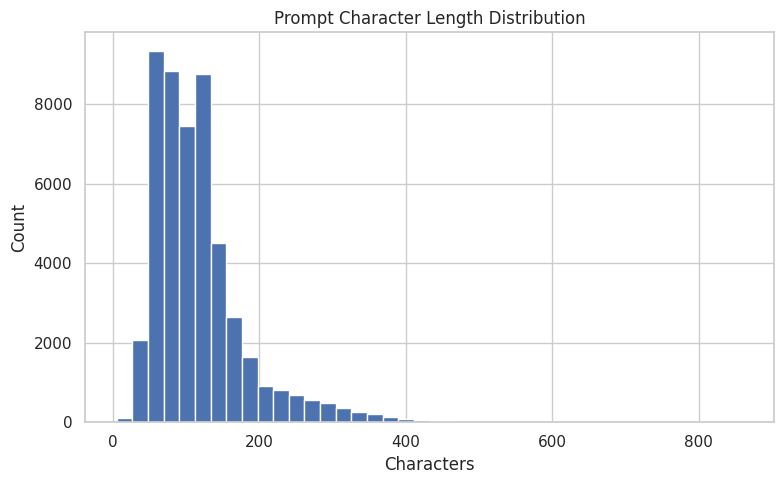

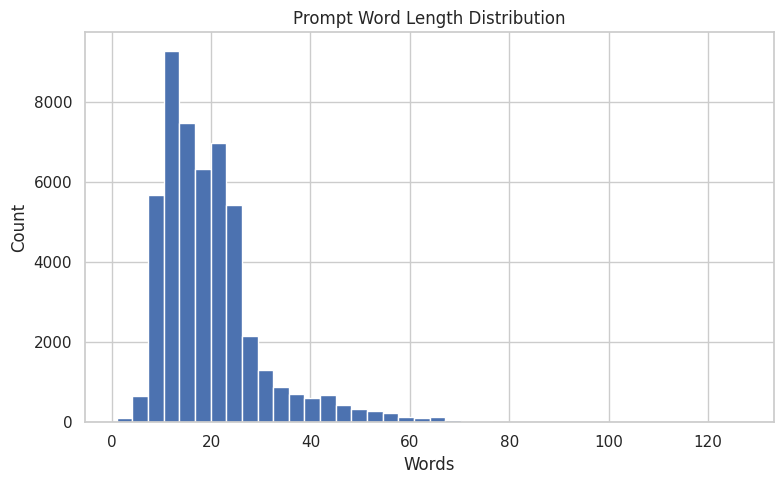

In [24]:
# Prompt length histograms
plt.figure(figsize=(8, 5))
plt.hist(train_dedup["prompt_len_chars"].dropna(), bins=40)
plt.title("Prompt Character Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "prompt_len_chars_hist.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(train_dedup["prompt_len_words"].dropna(), bins=40)
plt.title("Prompt Word Length Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "prompt_len_words_hist.png", dpi=150)
plt.show()


## SVG feature engineering

Length, tags, and frequency summaries from cleaned SVG.


In [25]:
train_dedup["svg_len_chars"] = train_dedup["svg_clean"].fillna("").astype(str).str.len()
train_dedup["svg_tags"] = train_dedup["svg_clean"].fillna("").apply(extract_svg_tags)
train_dedup["num_tags"] = train_dedup["svg_tags"].apply(len)
train_dedup["has_svg_wrapper"] = train_dedup["svg_clean"].fillna("").apply(has_svg_wrapper)

svg_feature_cols = [
    "svg_len_chars",
    "num_tags",
    "has_svg_wrapper",
]

display(train_dedup[svg_feature_cols].describe(include="all"))


,svg_len_chars,num_tags,has_svg_wrapper
count,50000.000000,50000.000000,50000
unique,NaN,NaN,2
top,NaN,NaN,True
freq,NaN,NaN,49999
mean,2495.933420,5.211720,NaN
std,1768.192093,5.348969,NaN
min,93.000000,1.000000,NaN
25%,1092.750000,3.000000,NaN
50%,2083.000000,4.000000,NaN
75%,3500.000000,5.000000,NaN


In [26]:
# Tag frequency counts
tag_counts = count_tag_frequencies(train_dedup["svg_tags"])
tag_counts_df = (
    pd.DataFrame(tag_counts.items(), columns=["tag", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

display(tag_counts_df.head(20))


,tag,count
0,path,120980
1,svg,99999
2,circle,13572
3,g,12191
4,rect,4321
5,stop,2819
6,radialgradient,1364
7,lineargradient,1124
8,clippath,782
9,ellipse,781


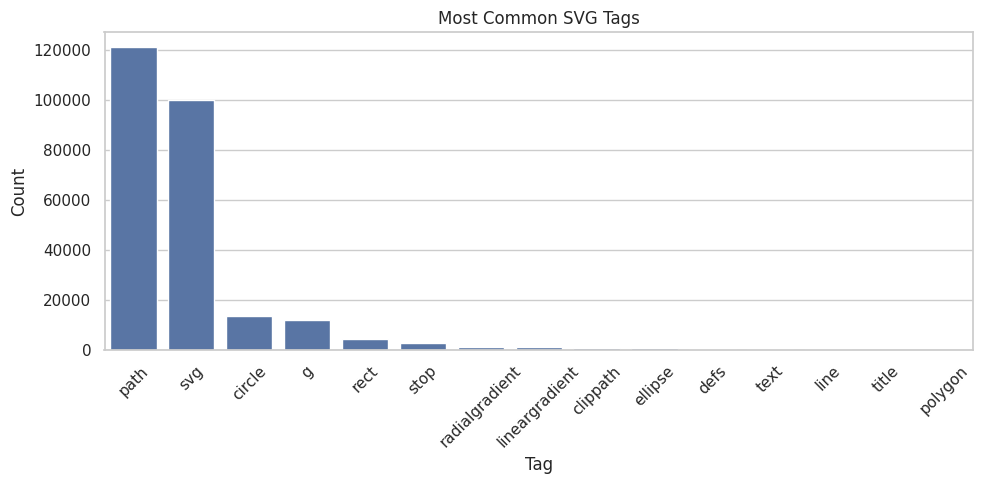

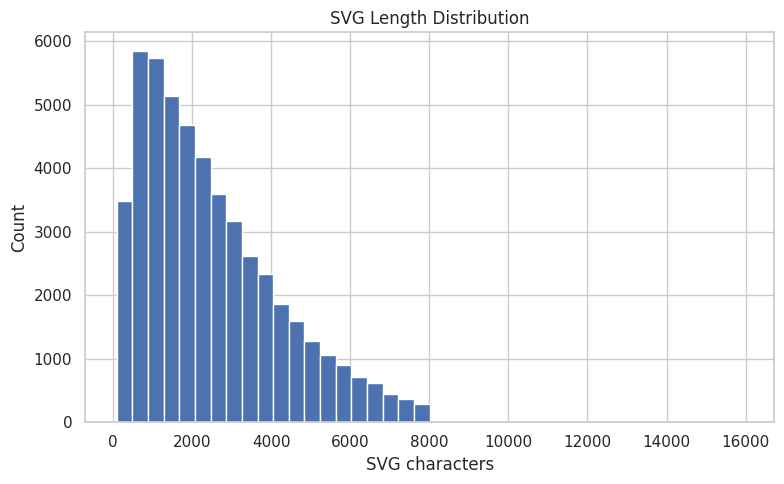

In [27]:
# Most common tags bar plot
top_n = min(15, len(tag_counts_df))
plot_df = tag_counts_df.head(top_n)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="tag", y="count")
plt.title("Most Common SVG Tags")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "most_common_svg_tags.png", dpi=150)
plt.show()

# SVG length histogram
plt.figure(figsize=(8, 5))
plt.hist(train_dedup["svg_len_chars"].dropna(), bins=40)
plt.title("SVG Length Distribution")
plt.xlabel("SVG characters")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "svg_len_chars_hist.png", dpi=150)
plt.show()


## SVG structure analysis

Per-row opening tag, viewBox, and drawable tag detection.


In [28]:
# Per-SVG structure analysis
train_dedup["opening_svg_tag"] = train_dedup["svg_clean"].apply(extract_opening_svg_tag)
train_dedup["svg_attributes"] = train_dedup["opening_svg_tag"].apply(extract_svg_attributes)
train_dedup["attribute_order"] = train_dedup["svg_attributes"].apply(lambda d: tuple(d.keys()))
train_dedup["viewBox_raw"] = train_dedup["svg_attributes"].apply(lambda d: d.get("viewBox"))
train_dedup["viewBox_parsed"] = train_dedup["viewBox_raw"].apply(parse_viewbox)
train_dedup["valid_viewBox"] = train_dedup["viewBox_raw"].apply(is_valid_viewbox)

train_dedup["drawable_tags"] = train_dedup["svg_clean"].apply(detect_drawable_tags)
train_dedup["num_drawable_tag_types"] = train_dedup["drawable_tags"].apply(lambda x: len(set(x)))

train_dedup["has_svg_open"] = train_dedup["svg_clean"].str.contains(r"<svg\b", case=False, regex=True, na=False)
train_dedup["has_svg_close"] = train_dedup["svg_clean"].str.contains(r"</svg>", case=False, regex=True, na=False)
train_dedup["has_xmlns"] = train_dedup["svg_clean"].apply(has_namespace)
train_dedup["has_width"] = train_dedup["svg_attributes"].apply(lambda d: "width" in d)
train_dedup["has_height"] = train_dedup["svg_attributes"].apply(lambda d: "height" in d)
train_dedup["has_viewBox"] = train_dedup["svg_attributes"].apply(lambda d: "viewBox" in d)

structure_cols = [
    "has_svg_open",
    "has_svg_close",
    "has_xmlns",
    "has_width",
    "has_height",
    "has_viewBox",
    "valid_viewBox",
    "attribute_order",
    "num_drawable_tag_types",
    "drawable_tags",
    "opening_svg_tag",
]
display(train_dedup[structure_cols].head(10))


,has_svg_open,has_svg_close,has_xmlns,has_width,has_height,has_viewBox,valid_viewBox,attribute_order,num_drawable_tag_types,drawable_tags,opening_svg_tag
0,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,"[path, path, path]","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
1,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,"[path, path, path, path]","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
2,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,"[path, path]","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
3,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,"[path, path]","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
4,True,True,True,True,True,True,True,"(width, height, viewBox, fill, xmlns)",2,"[rect, polygon]","<svg width=""256"" height=""256"" viewBox=""0 0 256 256"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">"
5,True,True,True,True,True,True,True,"(fill, height, viewBox, width, xmlns)",2,"[g, path, path, g]","<svg fill=""none"" height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
6,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,"[path, path, path, path]","<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
7,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,[path],"<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
8,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,[path],"<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"
9,True,True,True,True,True,True,True,"(viewBox, height, width, xmlns)",1,[path],"<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">"


## Aggregate structure analysis

Dataset-wide prevalence of structural features and common attribute patterns.


In [29]:
# Mean presence of structural features
structure_presence_cols = [
    "has_svg_open",
    "has_svg_close",
    "has_xmlns",
    "has_width",
    "has_height",
    "has_viewBox",
    "valid_viewBox",
]

structure_means = train_dedup[structure_presence_cols].mean().sort_values(ascending=False)
display(structure_means.to_frame("mean_presence").style.format("{:.2%}"))


,mean_presence
has_svg_open,100.00%
has_xmlns,100.00%
has_width,100.00%
has_viewBox,100.00%
has_height,100.00%
valid_viewBox,100.00%
has_svg_close,100.00%


In [30]:
# Most common attribute orders
attribute_order_counts = (
    train_dedup["attribute_order"]
    .value_counts()
    .rename_axis("attribute_order")
    .reset_index(name="count")
)
display(attribute_order_counts.head(20))


,attribute_order,count
0,"(viewBox, height, width, xmlns)",40893
1,"(height, viewBox, width, xmlns)",3709
2,"(fill, height, viewBox, width, xmlns)",1683
3,"(width, height, viewBox, xmlns)",1423
4,"(viewBox, width, height, xmlns)",457
5,"(enable-background, height, viewBox, width, xmlns)",446
6,"(viewBox, xmlns, width, height)",307
7,"(width, height, viewBox, fill, xmlns)",292
8,"(height, preserveAspectRatio, viewBox, width, xmlns)",215
9,"(clip-rule, fill-rule, height, image-rendering, shape-rendering, text-rendering, viewBox, width, xmlns)",100


In [31]:
# Most common drawable tag combinations
drawable_combo_counts = (
    train_dedup["drawable_tags"]
    .apply(lambda tags: tuple(sorted(set(tags))))
    .value_counts()
    .rename_axis("drawable_tag_combo")
    .reset_index(name="count")
)
display(drawable_combo_counts.head(20))


,drawable_tag_combo,count
0,"(path,)",44616
1,"(g, path)",1942
2,"(circle, g, rect)",571
3,"(circle, g, path)",442
4,"(circle, rect)",410
5,"(circle, g, path, rect)",375
6,"(circle, path)",275
7,"(circle, path, rect)",269
8,"(path, rect)",151
9,"(g, path, rect)",149


In [32]:
# Most common opening <svg> tags
opening_tag_counts = (
    train_dedup["opening_svg_tag"]
    .value_counts()
    .rename_axis("opening_svg_tag")
    .reset_index(name="count")
)
display(opening_tag_counts.head(20))


,opening_svg_tag,count
0,"<svg viewBox=""0 0 256 256"" height=""256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">",40893
1,"<svg height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">",3709
2,"<svg fill=""none"" height=""256"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">",1682
3,"<svg width=""256"" height=""256"" viewBox=""0 0 256 256"" xmlns=""http://www.w3.org/2000/svg"">",1423
4,"<svg viewBox=""0 0 256 256"" width=""256"" height=""256"" xmlns=""http://www.w3.org/2000/svg"">",457
5,"<svg viewBox=""0 0 256 256"" xmlns=""http://www.w3.org/2000/svg"" width=""256"" height=""256"">",307
6,"<svg width=""256"" height=""256"" viewBox=""0 0 256 256"" fill=""none"" xmlns=""http://www.w3.org/2000/svg"">",267
7,"<svg height=""256"" preserveAspectRatio=""xMidYMid meet"" viewBox=""0 0 256 256"" width=""256"" xmlns=""http://www.w3.org/2000/svg"">",158
8,"<svg clip-rule=""evenodd"" fill-rule=""evenodd"" height=""256"" image-rendering=""optimizeQuality"" shape-rendering=""geometricPrecision"" text-rendering=""geometricPrecision"" viewBox=""0 0 256 256"" width=""25...",100
9,"<svg enable-background=""new 0 0 128 128"" viewBox=""0 0 256 256"" xmlns=""http://www.w3.org/2000/svg"" width=""256"" height=""256"">",83


In [33]:
# Count unique opening tags and unique attribute orders
print("Unique opening <svg> tags:", train_dedup["opening_svg_tag"].nunique(dropna=True))
print("Unique attribute orders:", train_dedup["attribute_order"].nunique(dropna=True))


Unique opening <svg> tags: 199
Unique attribute orders: 69


In [34]:
# Optional: save an enriched analysis dataset for later notebooks
analysis_out_path = INTERIM_DIR / "train_clean_basic_with_features.csv"
train_dedup.to_csv(analysis_out_path, index=False)

print(f"Saved enriched analysis dataset to: {analysis_out_path}")


Saved enriched analysis dataset to: /content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL/data/interim/train_clean_basic_with_features.csv


## Notes

Helpers live in `src/svg/cleaning.py` and `src/svg/features.py`. Ensure the import cell ran so `sys.path` includes `PROJECT_DIR`.
